In [1]:
## Loading the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
%matplotlib inline

In [2]:
## Programme returns index of each point closest to the centroid
def find_closest_centroids(X, centroids):
    m = X.shape[0]
    k = centroids.shape[0]
    idx = np.zeros(m)
    for i in range(m):
        min_dist = 1000000
        for j in range(k):
            dist = np.sum((X[i,:] - centroids[j,:]) ** 2)
            if dist < min_dist:
                min_dist = dist
                idx[i] = j  
    return idx

In [3]:
## Loading the data containg three hundred points in the plane.
data = loadmat('ex7data2.mat')
X = data['X']
print(X.shape)
X[:10] # First 10 data

(300, 2)


array([[1.84207953, 4.6075716 ],
       [5.65858312, 4.79996405],
       [6.35257892, 3.2908545 ],
       [2.90401653, 4.61220411],
       [3.23197916, 4.93989405],
       [1.24792268, 4.93267846],
       [1.97619886, 4.43489674],
       [2.23454135, 5.05547168],
       [2.98340757, 4.84046406],
       [2.97970391, 4.80671081]])

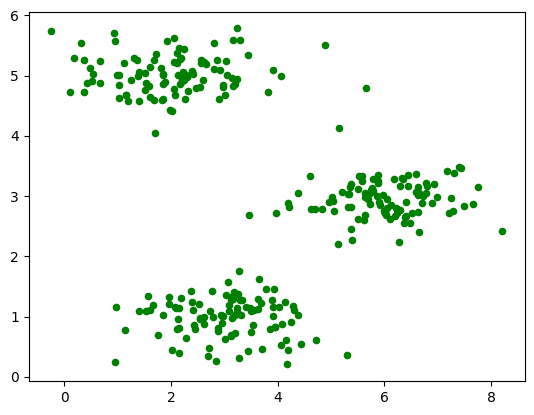

In [4]:
## Ploting the data
plt.scatter(X[:,0],X[:,1], color='green',s=20)
plt.show()

In [5]:
initial_centroids = np.array([[3, 3], [6, 2], [8, 5]])
idx = find_closest_centroids(X, initial_centroids)
print(idx)

[0. 2. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 1.
 1. 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 0. 1. 2. 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 0.]


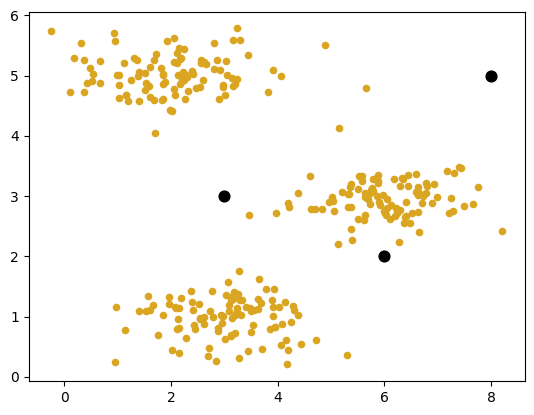

In [6]:
## Plotting data along with initial centroids
plt.scatter(X[:,0],X[:,1], color='goldenrod',s=20)
plt.scatter(initial_centroids[:,0],initial_centroids[:,1],color='black',s=60)
plt.show()

In [7]:
## Programme to find the centroid of each cluter
def compute_centroids(X, idx, k):
    m, n = X.shape
    centroids = np.zeros((k, n))
    for i in range(k):
        indices = np.where(idx == i)
        centroids[i,:] = (np.sum(X[indices,:], axis=1) / len(indices[0])).ravel()
    return centroids
    
compute_centroids(X, idx, 3)

array([[2.42830111, 3.15792418],
       [5.81350331, 2.63365645],
       [7.11938687, 3.6166844 ]])

In [8]:
## Programme to do k-means iterations
def run_k_means(X, initial_centroids, max_iters):
    m, n = X.shape
    k = initial_centroids.shape[0]
    idx = np.zeros(m)
    centroids = initial_centroids
    
    for i in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, k)
    
    return idx, centroids


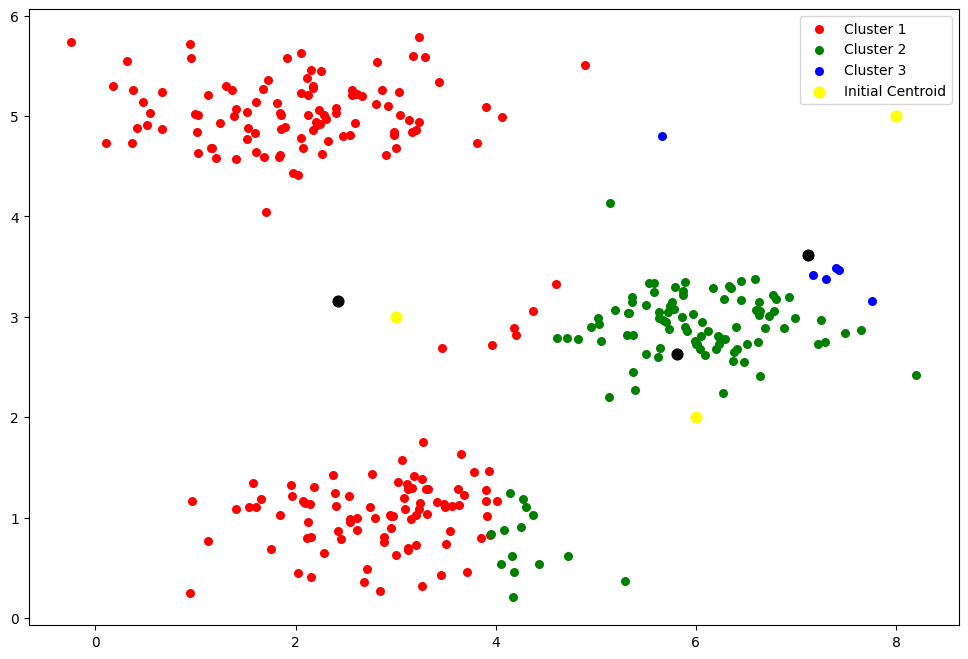

In [10]:
## Plotting points and clusters after 1 iteration
idx, centroids = run_k_means(X, initial_centroids, 1)
cluster1 = X[np.where(idx == 0)[0],:]
cluster2 = X[np.where(idx == 1)[0],:]
cluster3 = X[np.where(idx == 2)[0],:]
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(cluster1[:,0], cluster1[:,1], s=30, color='r', label='Cluster 1')
ax.scatter(cluster2[:,0], cluster2[:,1], s=30, color='g', label='Cluster 2')
ax.scatter(cluster3[:,0], cluster3[:,1], s=30, color='b', label='Cluster 3')
ax.scatter(centroids[:,0],centroids[:,1],color='black',s=60)
plt.scatter(initial_centroids[:,0],initial_centroids[:,1],color='yellow',s=60,label='Initial Centroid')

ax.legend()
plt.show()


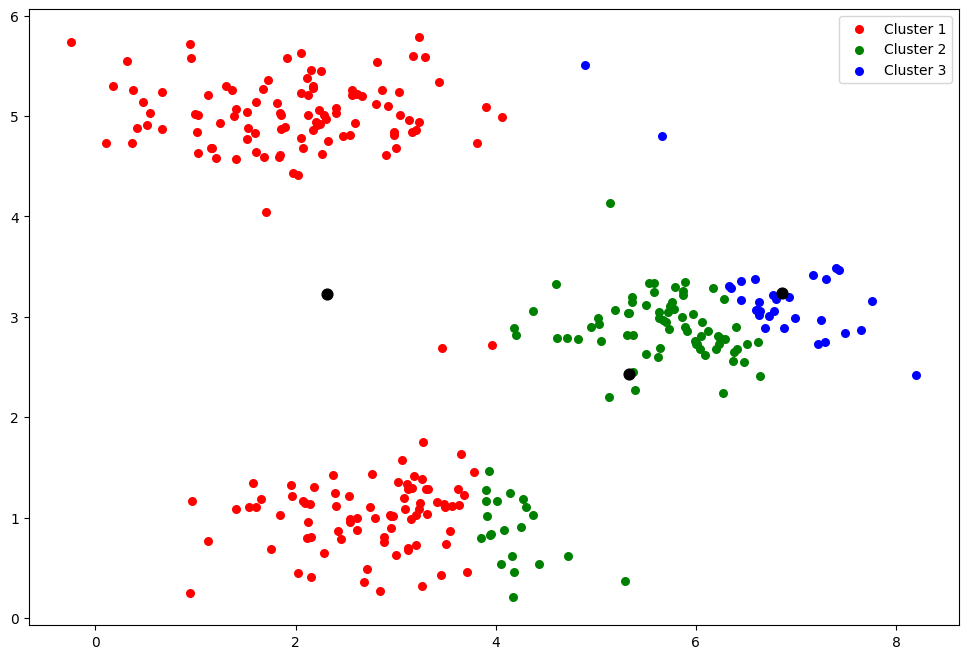

In [11]:
## 2nd iteration
idx, centroids = run_k_means(X, initial_centroids, 2)
cluster1 = X[np.where(idx == 0)[0],:]
cluster2 = X[np.where(idx == 1)[0],:]
cluster3 = X[np.where(idx == 2)[0],:]

fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(cluster1[:,0], cluster1[:,1], s=30, color='r', label='Cluster 1')
ax.scatter(cluster2[:,0], cluster2[:,1], s=30, color='g', label='Cluster 2')
ax.scatter(cluster3[:,0], cluster3[:,1], s=30, color='b', label='Cluster 3')
ax.scatter(centroids[:,0],centroids[:,1],color='black',s=60)

ax.legend()
plt.show()


In [12]:
## Creating initial centroids
def init_centroids(X, k):
    m, n = X.shape
    centroids = np.zeros((k, n))
    idx = np.random.randint(0, m, k)
    
    for i in range(k):
        centroids[i,:] = X[idx[i],:]
    
    return centroids

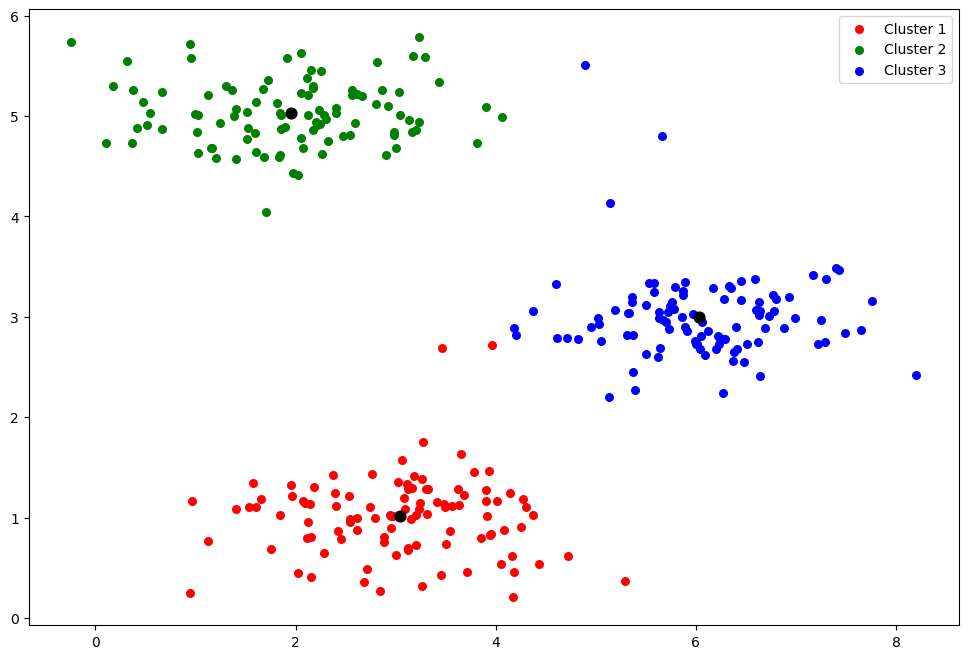

In [13]:
## Running the k-means clustering for N iterates
N = 100
idx, centroids = run_k_means(X, init_centroids(X, 3), N)
cluster1 = X[np.where(idx == 0)[0],:]
cluster2 = X[np.where(idx == 1)[0],:]
cluster3 = X[np.where(idx == 2)[0],:]
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(cluster1[:,0], cluster1[:,1], s=30, color='r', label='Cluster 1')
ax.scatter(cluster2[:,0], cluster2[:,1], s=30, color='g', label='Cluster 2')
ax.scatter(cluster3[:,0], cluster3[:,1], s=30, color='b', label='Cluster 3')
ax.scatter(centroids[:,0],centroids[:,1],color='black',s=60)

ax.legend()
plt.show()


# Mall Consumer data set example #

In [14]:
import pandas as pd
dataset=pd.read_csv('Mall_Customers.csv')

In [26]:
X = dataset.iloc[:, [3, 4]].values
m = X.shape[0]
n = X.shape[1]

Text(0.5, 1.0, 'Plot of data points')

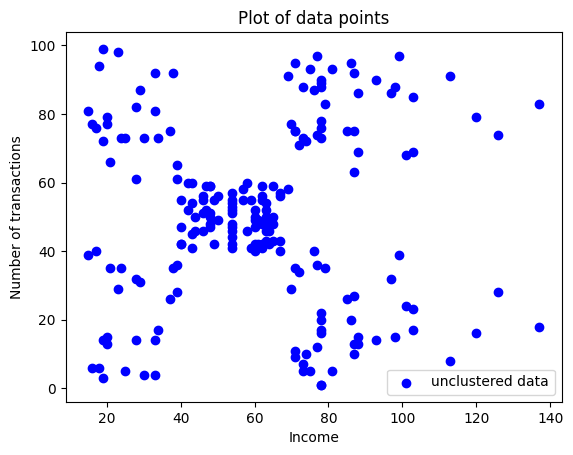

In [27]:
from matplotlib import pyplot as plt
plt.scatter(X[:,0],X[:,1],c='blue',label='unclustered data')
plt.xlabel('Income')
plt.ylabel('Number of transactions')
plt.legend()
plt.title('Plot of data points')

In [28]:
Centroids=np.array([]).reshape(n,0) 
Centroids

array([], shape=(2, 0), dtype=float64)

In [29]:
n_iter = 100
K=5 # number of clusters
for i in range(K):
    rand=np.random.randint(0,m-1)
    Centroids=np.c_[Centroids,X[rand]]

Text(0.5, 1.0, 'Plot of data points')

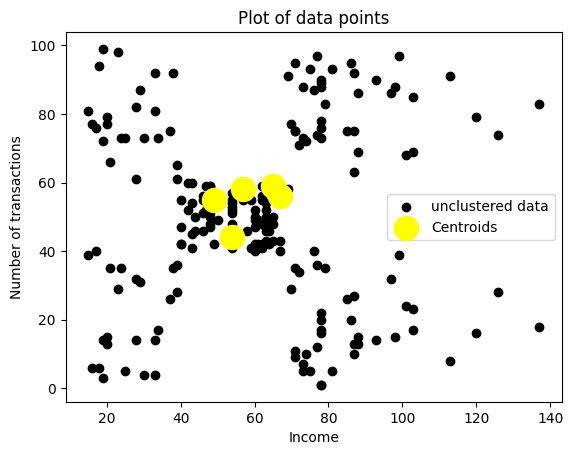

In [30]:
plt.scatter(X[:,0],X[:,1],c='black',label='unclustered data')
plt.scatter(Centroids[0,:],Centroids[1,:],s=300,c='yellow',label='Centroids')
plt.xlabel('Income')
plt.ylabel('Number of transactions')
plt.legend()
plt.title('Plot of data points')


In [31]:
idx, centroids = run_k_means(X, init_centroids(X, 5), 200)
cluster1 = X[np.where(idx == 0)[0],:]
cluster2 = X[np.where(idx == 1)[0],:]
cluster3 = X[np.where(idx == 2)[0],:]
cluster4 = X[np.where(idx == 3)[0],:]
cluster5 = X[np.where(idx == 4)[0],:]

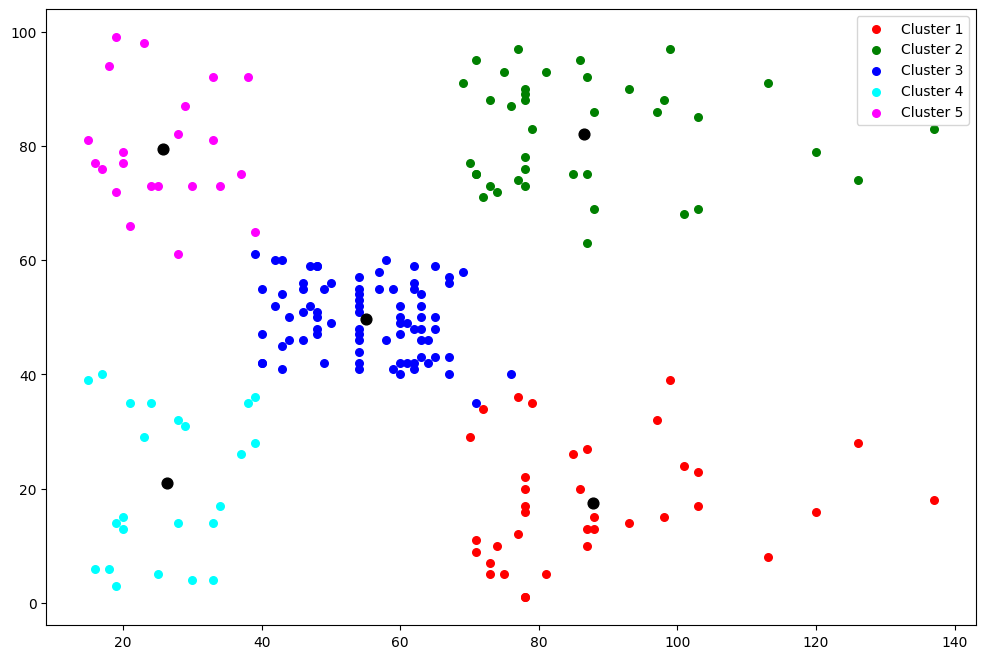

In [32]:
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(cluster1[:,0], cluster1[:,1], s=30, color='r', label='Cluster 1')
ax.scatter(cluster2[:,0], cluster2[:,1], s=30, color='g', label='Cluster 2')
ax.scatter(cluster3[:,0], cluster3[:,1], s=30, color='b', label='Cluster 3')
ax.scatter(cluster4[:,0], cluster4[:,1], s=30, color='cyan', label='Cluster 4')
ax.scatter(cluster5[:,0], cluster5[:,1], s=30, color='magenta', label='Cluster 5')
ax.scatter(centroids[:,0],centroids[:,1],color='black',s=60)

ax.legend()
plt.show()

# Elbow method #

In [33]:
### Elbow Method
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

In [35]:
from sklearn.cluster import KMeans  
wcss = []
for i in range(1, 11):  
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)  
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) 

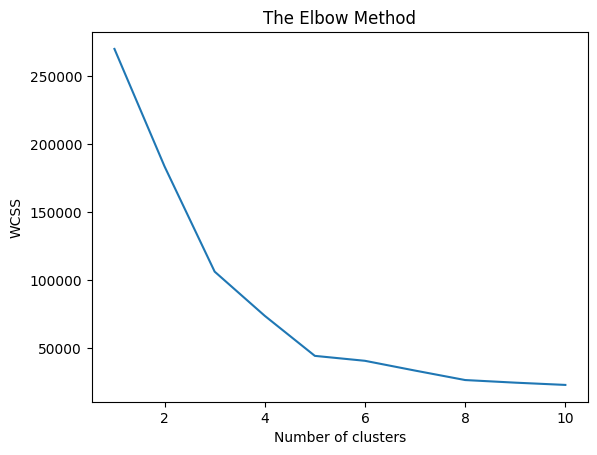

In [36]:
plt.plot(range(1, 11), wcss)  
plt.title('The Elbow Method')  
plt.xlabel('Number of clusters')  
plt.ylabel('WCSS')  
plt.show()

# Checking the quality of clustering for various number of k? #

In [37]:
############
# Load the dataset
df = pd.read_csv("Mall_Customers.csv")
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [39]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [41]:
###
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters, metric='euclidean')
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


In [42]:
##########
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sil_scores = []
for k in range(2, 11):  # silhouette not defined for k=1
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

sil_scores

[0.3212707813918878,
 0.46658474419000145,
 0.4939069237513199,
 0.5546571631111091,
 0.5398800926790663,
 0.5281492781108291,
 0.4552147906587443,
 0.4570853966942764,
 0.4431713026508046]

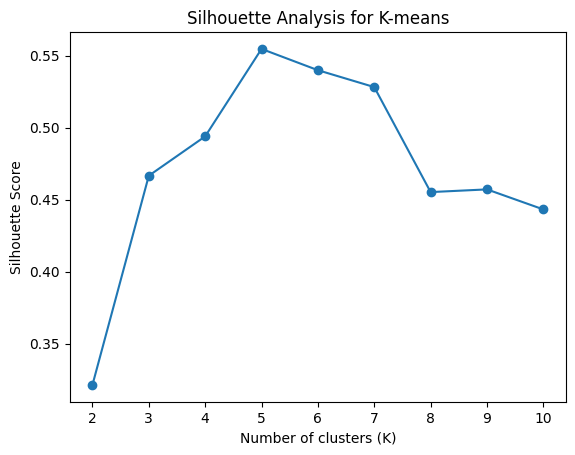

In [43]:
###########
import matplotlib.pyplot as plt

plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for K-means")
plt.show()